In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [97]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [98]:
print("Shape:", df.shape)

df.info()

Shape: (891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [99]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [100]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


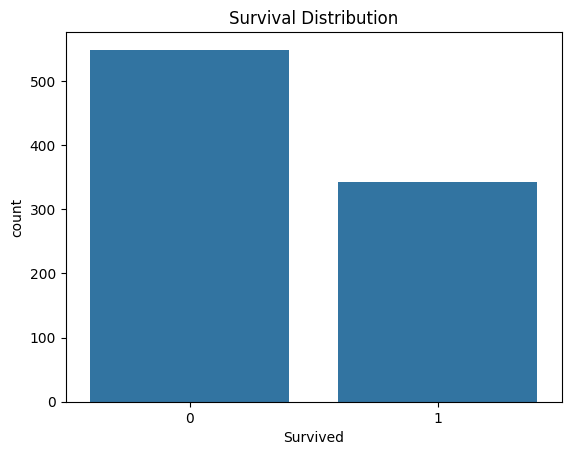

In [101]:
sns.countplot(x="Survived", data=df)

plt.title("Survival Distribution")

plt.savefig("images/survival_distribution.png")

plt.show()

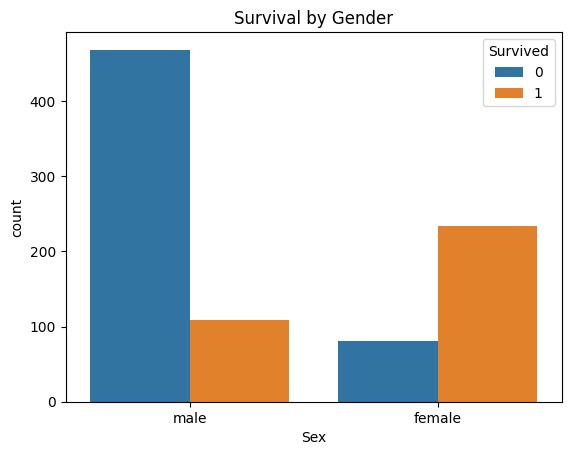

In [102]:
sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")

plt.savefig("images/survival_by_gender.png")

plt.show()

In [103]:
df["Age"] = df["Age"].fillna(df["Age"].median())

print("Age missing values:", df["Age"].isnull().sum())

Age missing values: 0


In [104]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print("Embarked missing values:", df["Embarked"].isnull().sum())

Embarked missing values: 0


In [105]:
df.drop("Cabin", axis=1, inplace=True)

print("Cabin column removed")

Cabin column removed


In [106]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [107]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

df["Sex"].head()

0    0
1    1
2    1
3    1
4    0
Name: Sex, dtype: int64

In [108]:
df["Embarked"] = df["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

df["Embarked"].head()

0    0
1    1
2    0
3    0
4    0
Name: Embarked, dtype: int64

In [109]:
X = df.drop(["Survived", "Name", "Ticket"], axis=1)
y = df["Survived"]

print(X.head())

   PassengerId  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0            1       3    0  22.0      1      0   7.2500         0
1            2       1    1  38.0      1      0  71.2833         1
2            3       3    1  26.0      0      0   7.9250         0
3            4       1    1  35.0      1      0  53.1000         0
4            5       3    0  35.0      0      0   8.0500         0


In [110]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (712, 8)
Testing Shape: (179, 8)


In [111]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Titanic Model Trained Successfully")

Titanic Model Trained Successfully


In [112]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 1 1 1 1 0 1 1]


In [113]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7988826815642458


In [114]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[89 16]
 [20 54]]


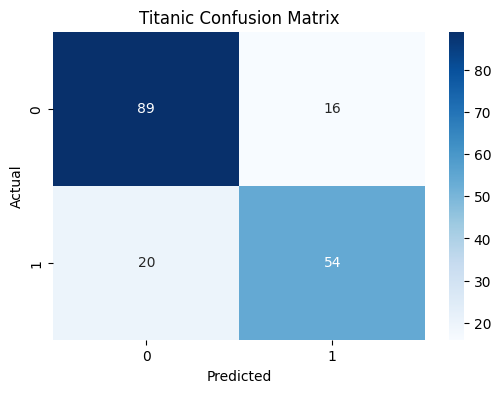

In [115]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Titanic Confusion Matrix")

plt.savefig("images/confusion_matrix.png")

plt.show()

In [116]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [117]:
import pickle

pickle.dump(
    model,
    open("titanic_model.pkl", "wb")
)

print("Model Saved Successfully")

Model Saved Successfully
